# Phase 6 - Inference and Confidence Calibration  

In this phase, we prepare the trained Facial Emotion Recognition model for reliable inference without building a web or webcam application. The focus is on loading the best trained model, rebuilding the preprocessing pipeline, running predictions on unseen images, and improving the reliability of confidence scores.

Since the previous evaluation showed that the model was slightly overconfident, temperature scaling is applied to calibrate the predicted probabilities. This does not change the predicted emotion class or macro-F1 score, but it makes the confidence values better aligned with the model’s actual accuracy.

The final output of this phase is a calibrated model checkpoint that can be reused for future inference or deployment if needed.



## 1. Imports and Setup

This section prepares the environment for the inference and deployment phase. It imports the required libraries for loading the trained model, preprocessing images, running predictions, evaluating results, and saving export-related files.

The code also selects the available device automatically, either GPU or CPU, and prints the GPU name when CUDA is available. Finally, an `exports` folder is created to store any generated inference outputs or saved deployment files.

In [1]:
import os, pickle, time, warnings, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.transforms as T, torchvision.models as models
from torchvision.models import EfficientNet_B2_Weights
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score
from PIL import Image
from tqdm.notebook import tqdm
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi":130,"axes.spines.top":False,"axes.spines.right":False})
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type=="cuda": print(f"GPU: {torch.cuda.get_device_name(0)}")
os.makedirs("exports", exist_ok=True)

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2. Load Configuration, Model, and Data Pipeline

This section loads the saved dataset configuration and rebuilds the trained Facial Emotion Recognition model for inference. The configuration restores the emotion labels, label mappings, image size, normalization values, and dataset paths used during training.

The model architecture is reconstructed using the same `EfficientNet-B2 + CBAM` structure, then the best saved checkpoint is loaded to restore the trained weights. The model is switched to evaluation mode so it can be used for stable prediction without training updates.

Finally, the preprocessing pipeline and dataset loaders are prepared for both the test set and a calibration split. The test loader is used to evaluate inference performance, while the calibration loader can be used later for confidence calibration such as temperature scaling.

In [2]:
with open("eda_outputs/data_pipeline_config.pkl","rb") as f: cfg=pickle.load(f)
EMOTIONS=cfg["EMOTIONS"]; NUM_CLASSES=cfg["NUM_CLASSES"]
LABEL2IDX=cfg["LABEL2IDX"]; IDX2LABEL=cfg["IDX2LABEL"]
DATASET_MEAN=cfg["DATASET_MEAN"]; DATASET_STD=cfg["DATASET_STD"]
IMG_SIZE=cfg["IMG_SIZE"]; DATASET_ROOT=Path(cfg["DATASET_ROOT"])
print("Config OK. Emotions:", EMOTIONS)

Config OK. Emotions: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [3]:
class CA(nn.Module):

    def __init__(self, ch, r=16):
        super().__init__()

        mid = max(ch // r, 8)

        self.shared_mlp = nn.Sequential(

            nn.Linear(ch, mid, bias=False),

            nn.ReLU(True),

            nn.Linear(mid, ch, bias=False)
        )

    def forward(self, x):

        B, C, H, W = x.shape

        g = torch.sigmoid(

            self.shared_mlp(x.mean([2,3])) +

            self.shared_mlp(x.amax([2,3]))
        )

        return x * g.view(B, C, 1, 1)


class SA(nn.Module):

    def __init__(self, k=7):
        super().__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            k,
            padding=k//2,
            bias=False
        )

    def forward(self, x):

        return x * torch.sigmoid(

            self.conv(
                torch.cat(
                    [x.mean(1,True), x.amax(1,True)],
                    1
                )
            )
        )


class CBAM(nn.Module):

    def __init__(self, ch, r=16, k=7):
        super().__init__()

        self.channel = CA(ch, r)

        self.spatial = SA(k)

    def forward(self, x):

        x = self.channel(x)

        x = self.spatial(x)

        return x


class FERHead(nn.Module):

    def __init__(
        self,
        in_f,
        nc=7,
        d1=0.4,
        d2=0.3
    ):
        super().__init__()

        self.head = nn.Sequential(

            nn.Linear(in_f, 512),

            nn.BatchNorm1d(512),

            nn.ReLU(True),

            nn.Dropout(d1),

            nn.Linear(512, 256),

            nn.BatchNorm1d(256),

            nn.ReLU(True),

            nn.Dropout(d2),

            nn.Linear(256, nc)
        )

    def forward(self, x):

        return self.head(x)


class FERModel(nn.Module):

    OUT = 1408

    def __init__(
        self,
        num_classes=7,
        pretrained=False,
        freeze_blocks=5,
        cbam_r=16,
        d1=0.4,
        d2=0.3
    ):
        super().__init__()

        bb = models.efficientnet_b2(

            weights=(
                EfficientNet_B2_Weights.IMAGENET1K_V1
                if pretrained else None
            )
        )

        self.features = bb.features

        self.avgpool = bb.avgpool

        for i, blk in enumerate(self.features):

            if i < freeze_blocks:

                for p in blk.parameters():

                    p.requires_grad = False

        self.cbam = CBAM(
            self.OUT,
            cbam_r
        )

        self.classifier = FERHead(
            self.OUT,
            num_classes,
            d1,
            d2
        )

    def forward(self, x):

        x = self.features(x)

        x = self.cbam(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        return self.classifier(x)


# ── Load checkpoint ─────────────────────────────────────────

ckpt = torch.load(
    "checkpoints/best_model.pt",
    map_location=device
)

cfg = ckpt["model_config"]

# rename old config keys
if "cbam_reduction" in cfg:
    cfg["cbam_r"] = cfg.pop("cbam_reduction")

if "dropout1" in cfg:
    cfg["d1"] = cfg.pop("dropout1")

if "dropout2" in cfg:
    cfg["d2"] = cfg.pop("dropout2")

cfg["pretrained"] = False

model = FERModel(
    **cfg
).to(device)

model.load_state_dict(
    ckpt["model_state"]
)

model.eval()

print(
    f"Loaded epoch={ckpt['epoch']} "
    f"macro-F1={ckpt['best_macro_f1']:.4f}"
)

Loaded epoch=40 macro-F1=0.6214


In [4]:
normalize=T.Normalize(mean=DATASET_MEAN,std=DATASET_STD)
INTERP=T.InterpolationMode.BICUBIC
val_tf=T.Compose([T.Resize((IMG_SIZE,IMG_SIZE),interpolation=INTERP),T.ToTensor(),normalize])
class FERDataset(Dataset):
    def __init__(self,root,split,tf=None):
        self.samples=[]; sd=Path(root)/split
        for em in EMOTIONS:
            ed=sd/em
            if not ed.exists(): continue
            for ext in ("*.jpg","*.jpeg","*.png"):
                for p in ed.glob(ext): self.samples.append((p,LABEL2IDX[em]))
        self.tf=tf
    def __len__(self): return len(self.samples)
    def __getitem__(self,i):
        p,l=self.samples[i]; img=Image.open(p).convert("RGB")
        return (self.tf(img) if self.tf else img),l
test_ds=FERDataset(DATASET_ROOT,"test",val_tf)
test_loader=DataLoader(test_ds,batch_size=256,shuffle=False,num_workers=4,pin_memory=True)
cal_split="val" if (DATASET_ROOT/"val").exists() else "train"
cal_ds=FERDataset(DATASET_ROOT,cal_split,val_tf)
cal_loader=DataLoader(cal_ds,batch_size=256,shuffle=False,num_workers=4,pin_memory=True)
print(f"Test:{len(test_ds):,}  Cal({cal_split}):{len(cal_ds):,}")

Test:7,178  Cal(val):4,303


## 3. Temperature Scaling

This section applies temperature scaling to improve the reliability of the model’s confidence scores. The model’s logits are collected from the calibration and test sets, then an optimal temperature value is learned using the calibration split.

Temperature scaling does not change the predicted class or macro-F1 score, but it adjusts the probability distribution to make confidence scores better aligned with actual accuracy. This is useful because the previous evaluation showed that the model was slightly overconfident.

The reliability diagrams compare calibration before and after temperature scaling. The Expected Calibration Error (ECE) decreases after applying the learned temperature, showing that the model’s confidence became more trustworthy for inference.

In [5]:
@torch.no_grad()
def collect_logits(model,loader):
    L,Y=[],[]
    for x,y in tqdm(loader,leave=False): L.append(model(x.to(device)).cpu()); Y+=y.tolist()
    return torch.cat(L),torch.tensor(Y)

def ece(logits,labels,n=10):
    p=F.softmax(logits,1); c=p.max(1).values; pred=p.argmax(1); ok=pred.eq(labels)
    e=0.0
    for lo,hi in zip(torch.linspace(0,1,n+1)[:-1],torch.linspace(0,1,n+1)[1:]):
        m=(c>=lo)&(c<hi)
        if m.any(): e+=(m.float().sum()/len(labels)).item()*abs(ok[m].float().mean().item()-c[m].mean().item())
    return e

cal_logits,cal_labels=collect_logits(model,cal_loader)
test_logits,test_labels=collect_logits(model,test_loader)

T_param=nn.Parameter(torch.ones(1,device=device))
nll=nn.CrossEntropyLoss()
opt=torch.optim.LBFGS([T_param],lr=0.01,max_iter=50)
cl=cal_logits.to(device); yl=cal_labels.to(device)
def eval_fn():
    opt.zero_grad(); loss=nll(cl/T_param,yl); loss.backward(); return loss
opt.step(eval_fn)
opt_temp=T_param.item()

ece_before=ece(test_logits,test_labels)
ece_after=ece(test_logits/opt_temp,test_labels)
print(f"T={opt_temp:.4f}  ECE: {ece_before:.4f} -> {ece_after:.4f}  ({(ece_before-ece_after)/ece_before*100:.1f}% improvement)")
preds=test_logits.argmax(1).tolist()
print(f"Macro-F1={f1_score(test_labels.tolist(),preds,average='macro'):.4f} (unchanged by temperature)")

  0%|          | 0/17 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

T=0.8779  ECE: 0.1049 -> 0.0610  (41.8% improvement)
Macro-F1=0.6140 (unchanged by temperature)


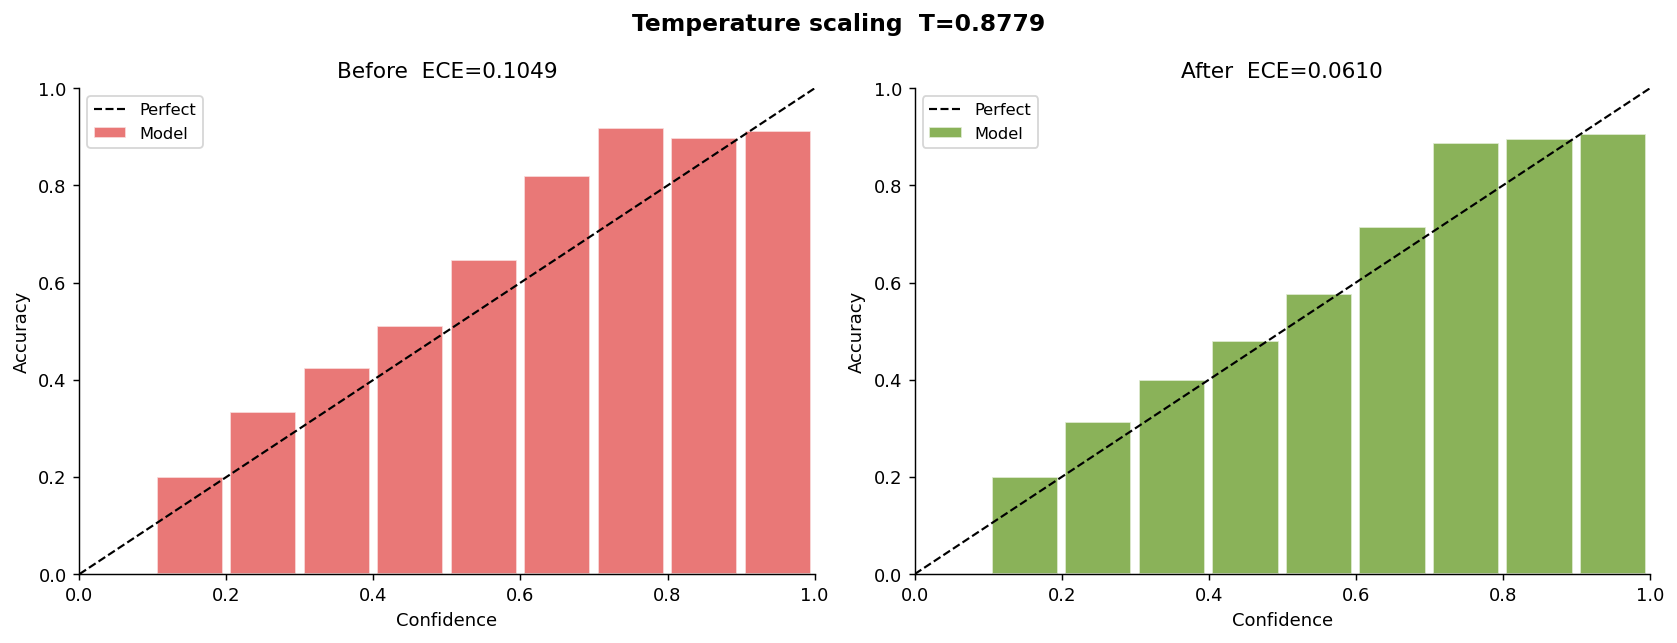

Saved temperature_scaling.png


In [6]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5))
for ax,logits,title,color in [
    (ax1,test_logits,f"Before  ECE={ece_before:.4f}","#E24B4A"),
    (ax2,test_logits/opt_temp,f"After  ECE={ece_after:.4f}","#639922")]:
    p=F.softmax(logits,1).numpy(); c=p.max(1); pred=p.argmax(1); ok=(pred==test_labels.numpy())
    bins=np.linspace(0,1,11)
    ba=[ok[(c>=lo)&(c<hi)].mean() if ((c>=lo)&(c<hi)).any() else 0
        for lo,hi in zip(bins[:-1],bins[1:])]
    ax.plot([0,1],[0,1],"k--",linewidth=1.2,label="Perfect")
    ax.bar([(lo+hi)/2 for lo,hi in zip(bins[:-1],bins[1:])],ba,width=0.09,
           alpha=0.75,color=color,edgecolor="white",label="Model")
    ax.set(title=title,xlabel="Confidence",ylabel="Accuracy",xlim=(0,1),ylim=(0,1))
    ax.legend(fontsize=9)
plt.suptitle(f"Temperature scaling  T={opt_temp:.4f}",fontsize=13,fontweight="bold")
plt.tight_layout(); plt.savefig("eda_outputs/temperature_scaling.png",bbox_inches="tight"); plt.show()
print("Saved temperature_scaling.png")

In [7]:
torch.save({"model_state":model.state_dict(),"temperature":opt_temp,
            "model_config":ckpt["model_config"],"phase2_config":cfg,
            "best_macro_f1":ckpt["best_macro_f1"],
            "ece_before":float(ece_before),"ece_after":float(ece_after)},
           "checkpoints/calibrated_model.pt")
print(f"Saved calibrated_model.pt  T={opt_temp:.4f}")

Saved calibrated_model.pt  T=0.8779
